In [1]:
# Instalación de la librería para balanceo
!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y Machine Learning
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Preparación de los Datos

In [4]:

df = pd.read_csv('datos_tratados.csv')
print("Forma original de los datos:", df.shape)

#Eliminación de Columnas Irrelevantes
if 'Cliente_ID' in df.columns:
    df = df.drop('Cliente_ID', axis=1)
    print("Columna 'Cliente_ID' eliminada exitosamente.")

# Definimos nuestra variable objetivo
target_col = 'Evasion'

# Encoding
# Convertimos las variables categóricas a numéricas usando One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)
print("\nCantidad de columnas después del Encoding:", df_encoded.shape[1])

# Verificación de la Proporción de Cancelación (Churn/Evasion)
print("\n--- Proporción de Evasión (Cancelación) ---")
print(df_encoded[target_col].value_counts(normalize=True) * 100)

# Eliminar filas con NaN en la columna objetivo antes de separar X e y
df_encoded.dropna(subset=[target_col], inplace=True)

# Separación de características (X) y etiqueta (y)
X = df_encoded.drop(target_col, axis=1)
y = df_encoded[target_col]

#Balanceo de Clases usando SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nDistribución de Evasión ANTES de SMOTE:")
print(y.value_counts())
print("\nDistribución de Evasión DESPUÉS de SMOTE:")
print(y_resampled.value_counts())

Forma original de los datos: (7267, 22)
Columna 'Cliente_ID' eliminada exitosamente.

Cantidad de columnas después del Encoding: 32

--- Proporción de Evasión (Cancelación) ---
Evasion
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64

Distribución de Evasión ANTES de SMOTE:
Evasion
0.0    5174
1.0    1869
Name: count, dtype: int64

Distribución de Evasión DESPUÉS de SMOTE:
Evasion
0.0    5174
1.0    5174
Name: count, dtype: int64


Correlación y Selección de Variables

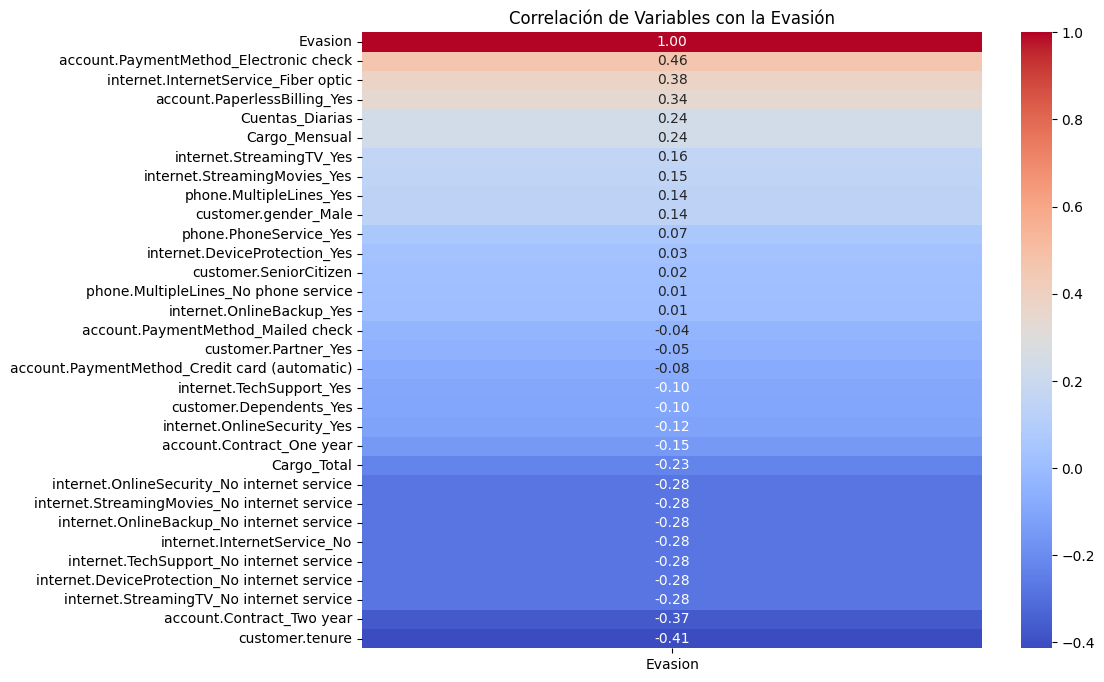

/tmp/ipykernel_9822/3178163646.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No (0)', 'Sí (1)'])
/tmp/ipykernel_9822/3178163646.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No (0)', 'Sí (1)'])


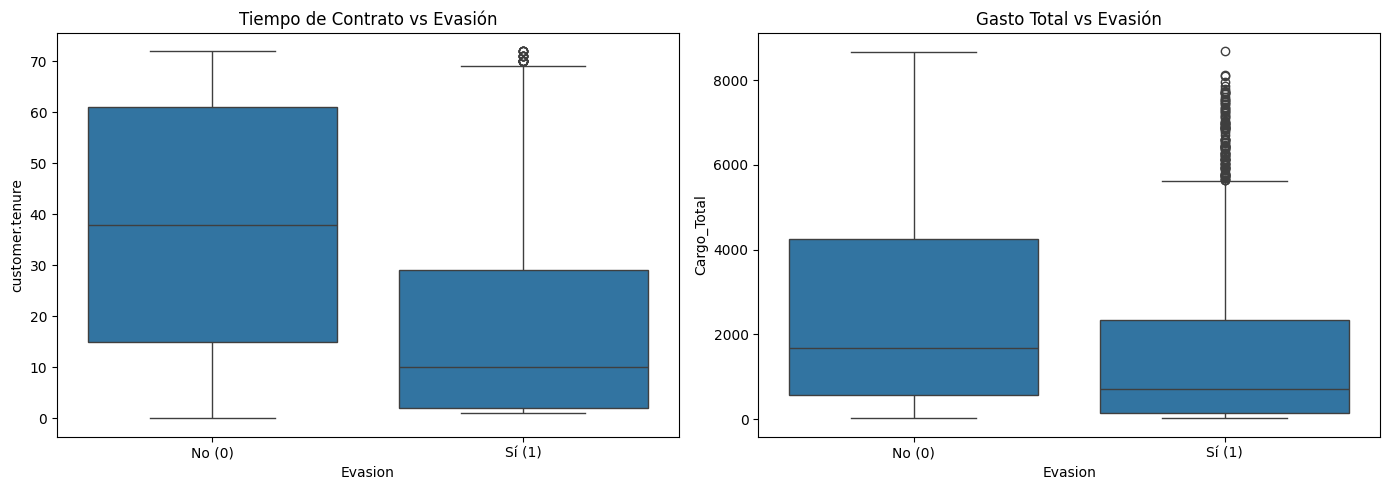

In [5]:
#Análisis de Correlación
plt.figure(figsize=(10, 8))

df_balanceado = pd.DataFrame(X_resampled, columns=X.columns)
df_balanceado[target_col] = y_resampled

correlacion = df_balanceado.corr()
# Filtramos solo la correlación respecto a 'Evasion' y ordenamos
corr_target = correlacion[[target_col]].sort_values(by=target_col, ascending=False)

sns.heatmap(corr_target, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación de Variables con la Evasión')
plt.show()

# Análisis Dirigido
# Evaluamos Tiempo de Contrato vs Evasión y Gasto Total vs Evasión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(ax=axes[0], x='Evasion', y='customer.tenure', data=df)
axes[0].set_title('Tiempo de Contrato vs Evasión')
axes[0].set_xticklabels(['No (0)', 'Sí (1)'])

sns.boxplot(ax=axes[1], x='Evasion', y='Cargo_Total', data=df)
axes[1].set_title('Gasto Total vs Evasión')
axes[1].set_xticklabels(['No (0)', 'Sí (1)'])

plt.tight_layout()
plt.show()

# Modelado Predictivo


--- Resultados de Regresión Logística ---
Exactitud (Accuracy): 0.8280
Precisión (Precision): 0.8432
Recall:               0.8092
F1-Score:             0.8258


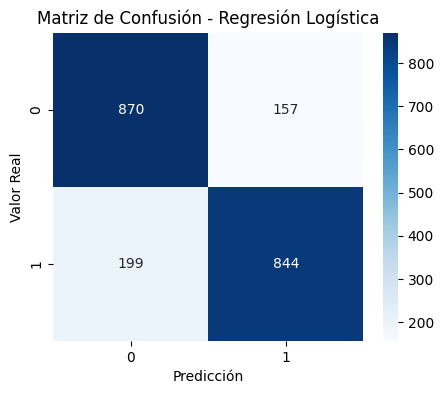


--- Resultados de Random Forest ---
Exactitud (Accuracy): 0.8527
Precisión (Precision): 0.8583
Recall:               0.8476
F1-Score:             0.8529


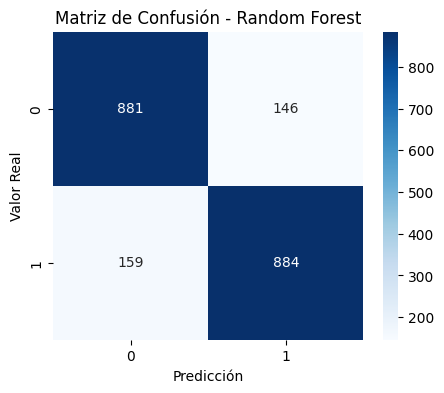

In [6]:
#  Separación de Datos (80% Entrenamiento, 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Estandarizamos para la Regresión Logística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creación y Evaluación de Modelos
def evaluar_modelo(y_true, y_pred, nombre_modelo):
    print(f"\n--- Resultados de {nombre_modelo} ---")
    print(f"Exactitud (Accuracy): {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precisión (Precision): {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:               {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:             {f1_score(y_true, y_pred):.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión - {nombre_modelo}')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

# Regresión Logística (Usa datos normalizados)
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
evaluar_modelo(y_test, y_pred_log, "Regresión Logística")

#  Random Forest
rf_clf = RandomForestClassifier(random_state=42, n_estimators=100)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
evaluar_modelo(y_test, y_pred_rf, "Random Forest")

#Interpretación de Variables

/tmp/ipykernel_9822/1886746127.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variable', data=importancia_log.head(10), palette='coolwarm')


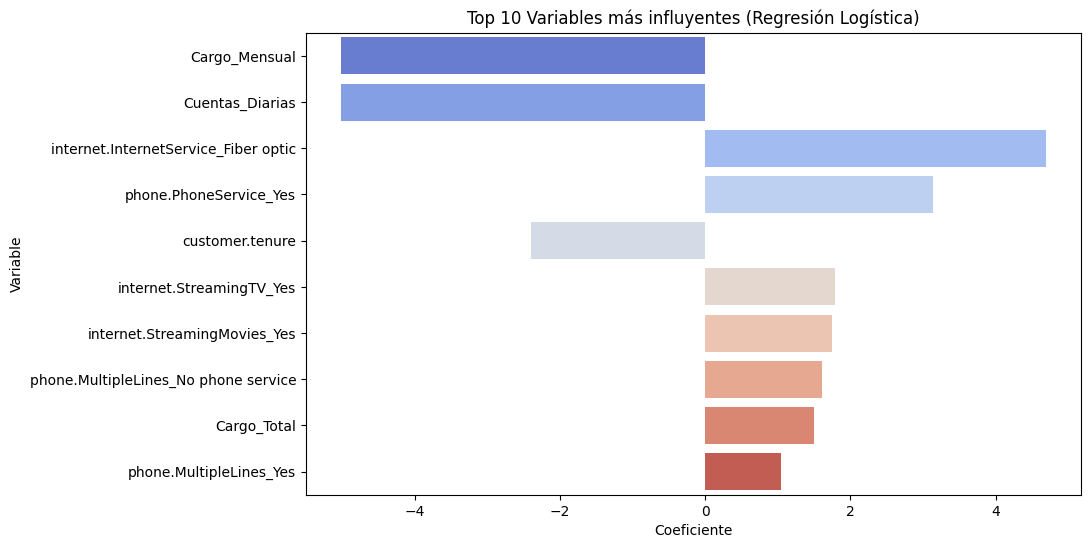

/tmp/ipykernel_9822/1886746127.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancia_rf.head(10), palette='viridis')


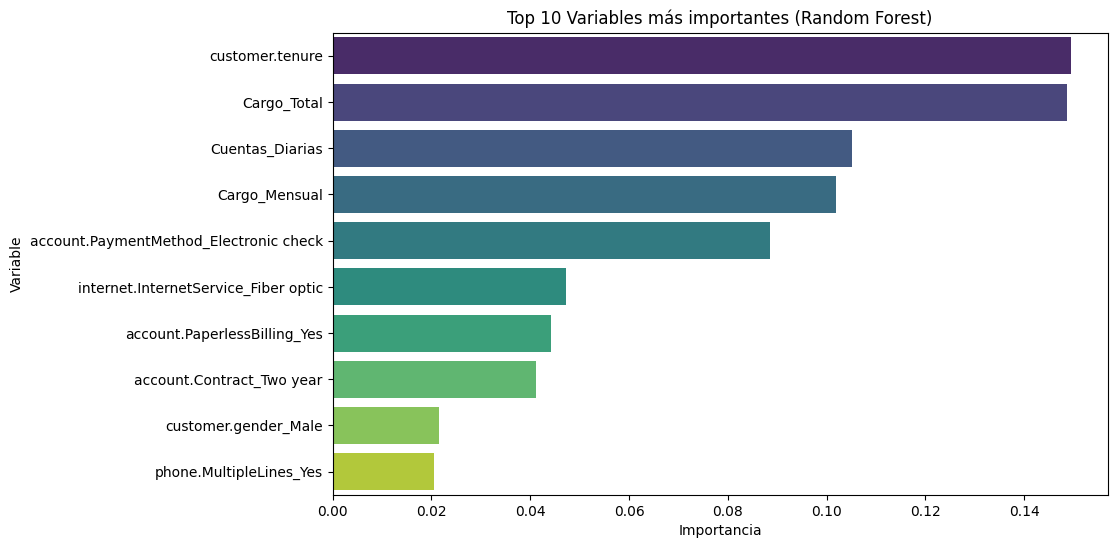

In [7]:
# Importancia en Regresión Logística (Coeficientes)
importancia_log = pd.DataFrame({'Variable': X.columns, 'Coeficiente': log_reg.coef_[0]})
# Coeficientes absolutos para ver magnitud
importancia_log['Magnitud'] = np.abs(importancia_log['Coeficiente'])
importancia_log = importancia_log.sort_values(by='Magnitud', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coeficiente', y='Variable', data=importancia_log.head(10), palette='coolwarm')
plt.title('Top 10 Variables más influyentes (Regresión Logística)')
plt.show()

# Importancia en Random Forest
importancia_rf = pd.DataFrame({'Variable': X.columns, 'Importancia': rf_clf.feature_importances_})
importancia_rf = importancia_rf.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importancia_rf.head(10), palette='viridis')
plt.title('Top 10 Variables más importantes (Random Forest)')
plt.show()